# Univariate Analysis

This notebook analyzes one variable at a time using the cleaned fraud detection dataset. The goal is to understand the distribution, spread, skewness, and outlier behavior of each feature before feature engineering and model training.

## 1. Objectives

This notebook focuses on the following tasks:

- load the cleaned dataset
- review target distribution after cleaning
- summarize each numerical variable individually
- inspect skewness and outlier behavior
- analyze `Amount` and `Time` in more detail
- save univariate tables, figures, and notes for later stages

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.append(str(Path("..").resolve()))

from src.config import AMOUNT_COLUMN, NUMERICAL_COLUMNS, PCA_COLUMNS, PROJECT_ROOT, TARGET_COLUMN, TIME_COLUMN
from src.data.data_loader import load_cleaned_data

NOTEBOOK_TABLES_DIR = PROJECT_ROOT / "reports" / "tables" / "05_univariate_analysis"
NOTEBOOK_FIGURES_DIR = PROJECT_ROOT / "reports" / "figures" / "05_univariate_analysis"
NOTEBOOK_TABLES_DIR.mkdir(parents=True, exist_ok=True)
NOTEBOOK_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")

print("Imports OK")
print(f"  Target column      : {TARGET_COLUMN}")
print(f"  Numerical columns  : {len(NUMERICAL_COLUMNS)}")
print(f"  Tables dir         : {NOTEBOOK_TABLES_DIR}")
print(f"  Figures dir        : {NOTEBOOK_FIGURES_DIR}")

Imports OK
  Target column      : Class
  Numerical columns  : 30
  Tables dir         : /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/05_univariate_analysis
  Figures dir        : /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/figures/05_univariate_analysis


## 2. Load Cleaned Data

In [2]:
df = load_cleaned_data()

print("Cleaned dataset shape:", df.shape)
df.head()

Cleaned dataset shape: (283726, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 3. Target Distribution After Cleaning

In [3]:
target_summary = pd.DataFrame({
    "count": df[TARGET_COLUMN].value_counts().sort_index(),
    "percent": (df[TARGET_COLUMN].value_counts(normalize=True).sort_index() * 100).round(4)
})
target_summary.index.name = TARGET_COLUMN
target_summary.to_csv(NOTEBOOK_TABLES_DIR / "target_distribution_after_cleaning.csv")
target_summary

,count,percent
Class,,
0,283253,99.8333
1,473,0.1667


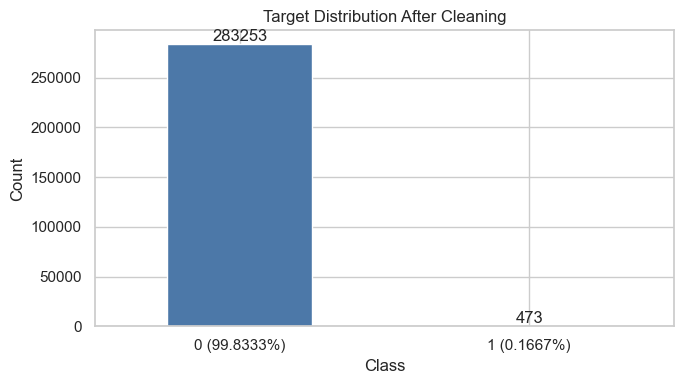

In [4]:
ax = target_summary["count"].plot(kind="bar", color=["#4C78A8", "#E45756"], figsize=(7, 4))
ax.set_title("Target Distribution After Cleaning")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
ax.set_xticklabels([f"{idx} ({target_summary.loc[idx, 'percent']:.4f}%)" for idx in target_summary.index], rotation=0)
for i, value in enumerate(target_summary["count"].values):
    ax.text(i, value, f"{value}", ha="center", va="bottom")
plt.tight_layout()
plt.savefig(NOTEBOOK_FIGURES_DIR / "target_distribution_after_cleaning.png", dpi=300, bbox_inches="tight")
plt.show()

## 4. Summary Statistics

In [5]:
summary_statistics = df[NUMERICAL_COLUMNS].describe().T
summary_statistics.to_csv(NOTEBOOK_TABLES_DIR / "summary_statistics.csv")
summary_statistics

,count,mean,std,min,25%,50%,75%,max
Time,283726.0,94811.077600,47481.047891,0.000000,54204.750000,84692.500000,139298.000000,172792.000000
V1,283726.0,0.005917,1.948026,-56.407510,-0.915951,0.020384,1.316068,2.454930
V2,283726.0,-0.004135,1.646703,-72.715728,-0.600321,0.063949,0.800283,22.057729
V3,283726.0,0.001613,1.508682,-48.325589,-0.889682,0.179963,1.026960,9.382558
V4,283726.0,-0.002966,1.414184,-5.683171,-0.850134,-0.022248,0.739647,16.875344
V5,283726.0,0.001828,1.377008,-113.743307,-0.689830,-0.053468,0.612218,34.801666
V6,283726.0,-0.001139,1.331931,-26.160506,-0.769031,-0.275168,0.396792,73.301626
V7,283726.0,0.001801,1.227664,-43.557242,-0.552509,0.040859,0.570474,120.589494
V8,283726.0,-0.000854,1.179054,-73.216718,-0.208828,0.021898,0.325704,20.007208
V9,283726.0,-0.001596,1.095492,-13.434066,-0.644221,-0.052596,0.595977,15.594995


In [6]:
skewness_summary = pd.DataFrame({
    "skewness": df[NUMERICAL_COLUMNS].skew().sort_values(ascending=False),
    "kurtosis": df[NUMERICAL_COLUMNS].kurtosis().reindex(df[NUMERICAL_COLUMNS].skew().sort_values(ascending=False).index)
})
skewness_summary.to_csv(NOTEBOOK_TABLES_DIR / "skewness_summary.csv")
skewness_summary.head(10)

,skewness,kurtosis
Amount,16.978803,844.471319
V28,11.555115,959.379812
V7,2.890271,414.142188
V21,2.820033,184.818126
V6,1.829880,42.838886
V10,1.252967,29.843899
V4,0.671504,2.618780
V26,0.580292,0.923557
V9,0.537663,3.516661
V11,0.344074,1.546849


## 5. Amount Analysis

In [7]:
amount_summary = df[[AMOUNT_COLUMN]].describe().T
amount_summary["skewness"] = df[AMOUNT_COLUMN].skew()
amount_summary.to_csv(NOTEBOOK_TABLES_DIR / "amount_summary.csv")
amount_summary

,count,mean,std,min,25%,50%,75%,max,skewness
Amount,283726.0,88.472687,250.399437,0.0,5.6,22.0,77.51,25691.16,16.978803


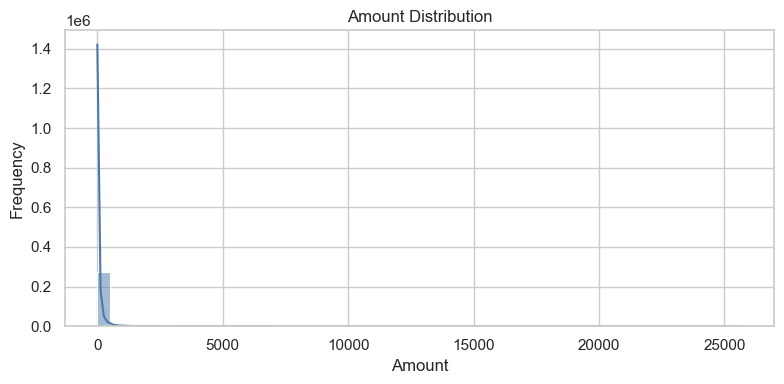

In [8]:
plt.figure(figsize=(8, 4))
sns.histplot(df[AMOUNT_COLUMN], bins=50, kde=True, color="#4C78A8")
plt.title("Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(NOTEBOOK_FIGURES_DIR / "amount_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

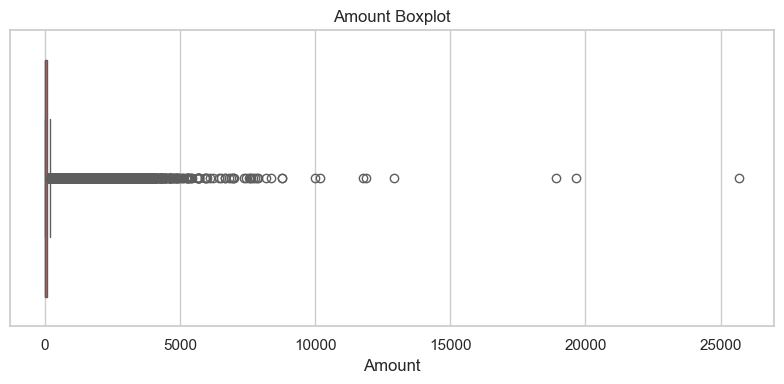

In [9]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df[AMOUNT_COLUMN], color="#E45756")
plt.title("Amount Boxplot")
plt.xlabel("Amount")
plt.tight_layout()
plt.savefig(NOTEBOOK_FIGURES_DIR / "amount_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

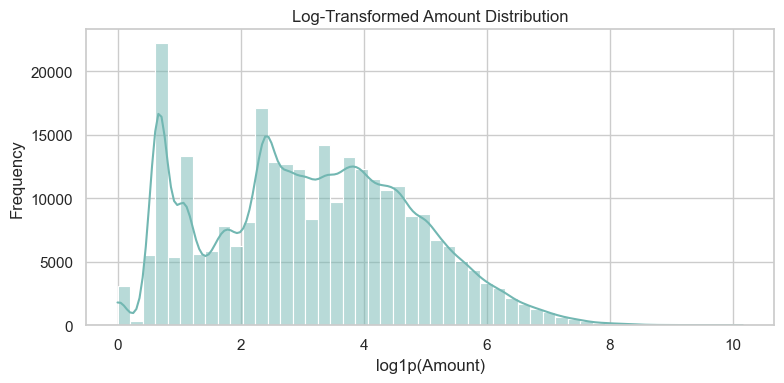

In [10]:
df["Amount_log"] = np.log1p(df[AMOUNT_COLUMN])

plt.figure(figsize=(8, 4))
sns.histplot(df["Amount_log"], bins=50, kde=True, color="#72B7B2")
plt.title("Log-Transformed Amount Distribution")
plt.xlabel("log1p(Amount)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(NOTEBOOK_FIGURES_DIR / "amount_log_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. Time Analysis

In [11]:
time_summary = df[[TIME_COLUMN]].describe().T
time_summary["skewness"] = df[TIME_COLUMN].skew()
time_summary.to_csv(NOTEBOOK_TABLES_DIR / "time_summary.csv")
time_summary

,count,mean,std,min,25%,50%,75%,max,skewness
Time,283726.0,94811.0776,47481.047891,0.0,54204.75,84692.5,139298.0,172792.0,-0.035581


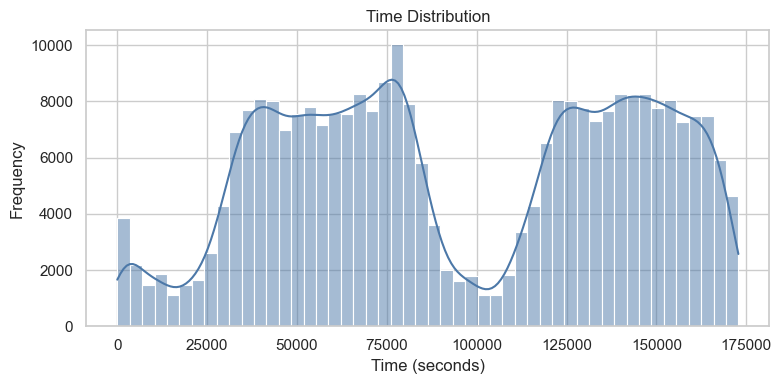

In [12]:
plt.figure(figsize=(8, 4))
sns.histplot(df[TIME_COLUMN], bins=50, kde=True, color="#4C78A8")
plt.title("Time Distribution")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(NOTEBOOK_FIGURES_DIR / "time_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

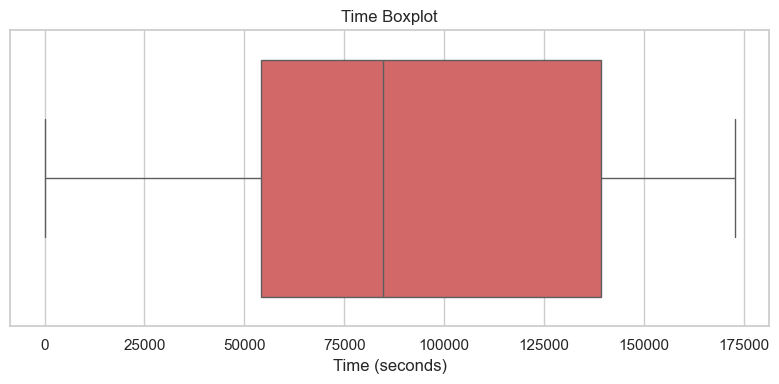

In [13]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df[TIME_COLUMN], color="#E45756")
plt.title("Time Boxplot")
plt.xlabel("Time (seconds)")
plt.tight_layout()
plt.savefig(NOTEBOOK_FIGURES_DIR / "time_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. PCA Feature Analysis

In [14]:
pca_summary = df[PCA_COLUMNS].describe().T
pca_summary["skewness"] = df[PCA_COLUMNS].skew()
pca_summary.to_csv(NOTEBOOK_TABLES_DIR / "pca_feature_summary.csv")
pca_summary.head()

,count,mean,std,min,25%,50%,75%,max,skewness
V1,283726.0,0.005917,1.948026,-56.407510,-0.915951,0.020384,1.316068,2.454930,-3.273271
V2,283726.0,-0.004135,1.646703,-72.715728,-0.600321,0.063949,0.800283,22.057729,-4.695162
V3,283726.0,0.001613,1.508682,-48.325589,-0.889682,0.179963,1.026960,9.382558,-2.151984
V4,283726.0,-0.002966,1.414184,-5.683171,-0.850134,-0.022248,0.739647,16.875344,0.671504
V5,283726.0,0.001828,1.377008,-113.743307,-0.689830,-0.053468,0.612218,34.801666,-2.414079


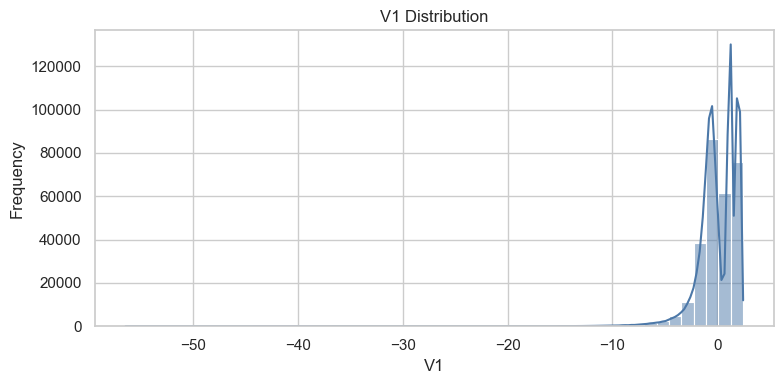

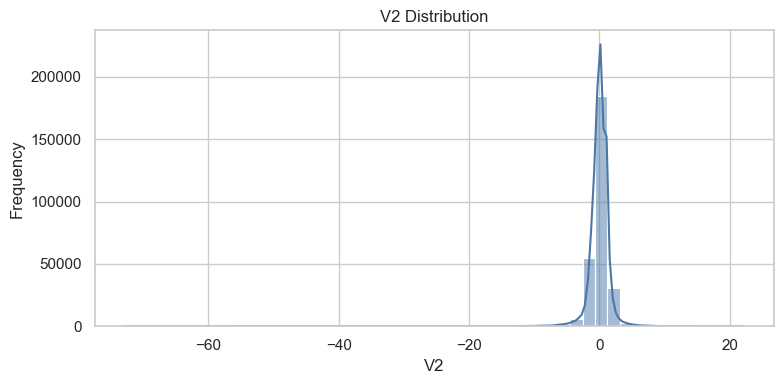

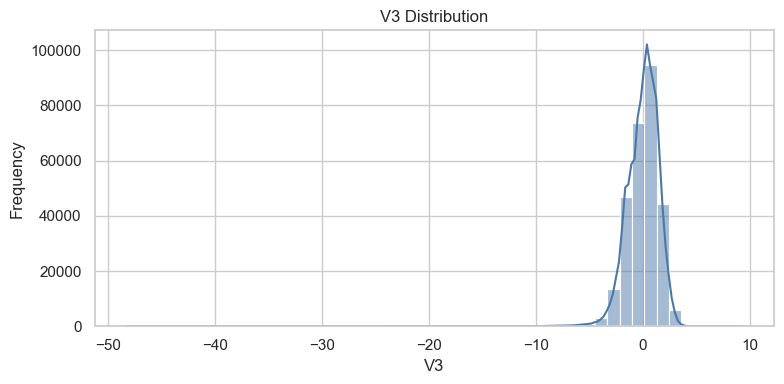

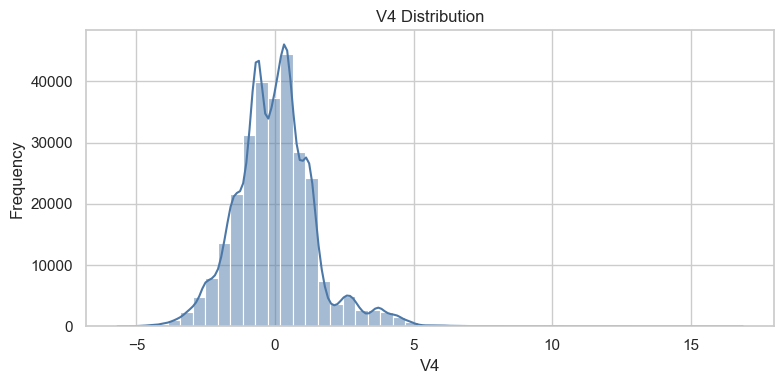

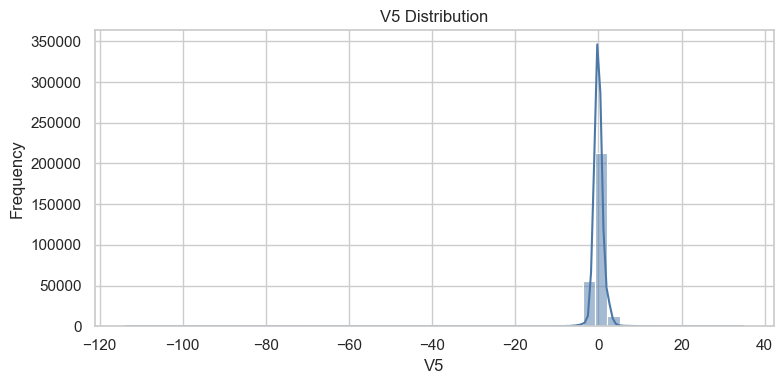

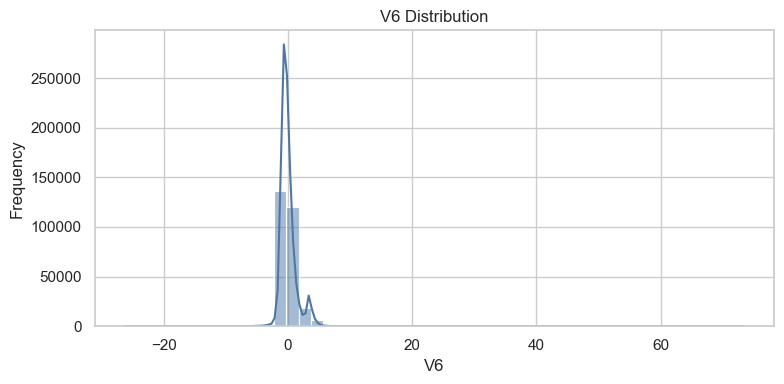

In [15]:
selected_pca_features = PCA_COLUMNS[:6]

for feature in selected_pca_features:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[feature], bins=50, kde=True, color="#4C78A8")
    plt.title(f"{feature} Distribution")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig(NOTEBOOK_FIGURES_DIR / f"{feature.lower()}_distribution.png", dpi=300, bbox_inches="tight")
    plt.show()

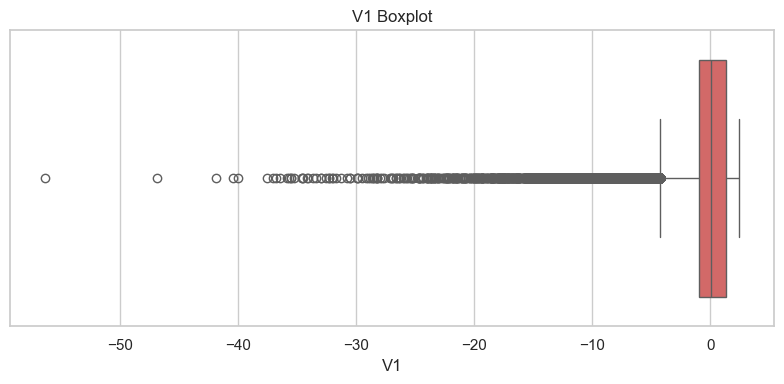

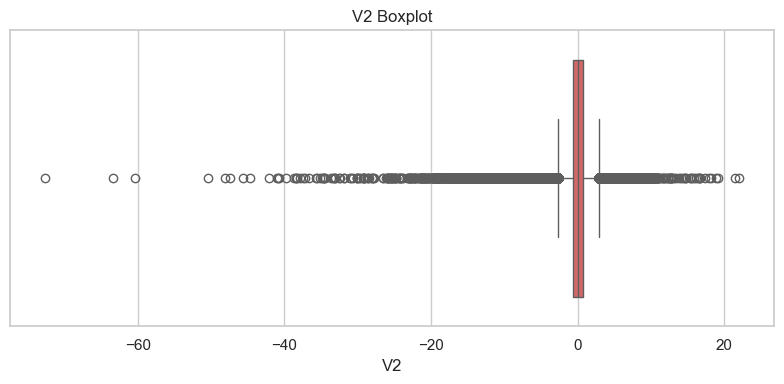

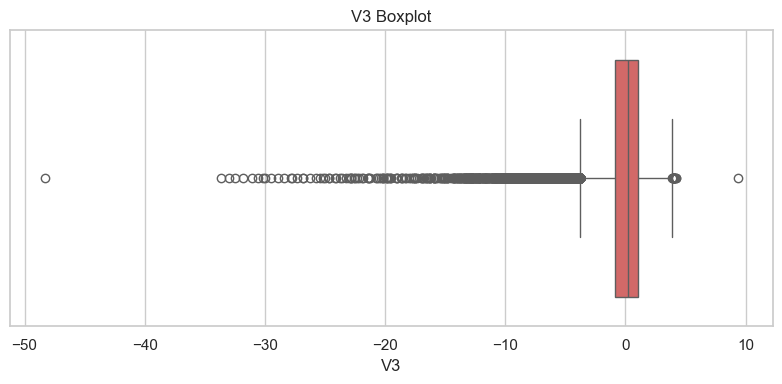

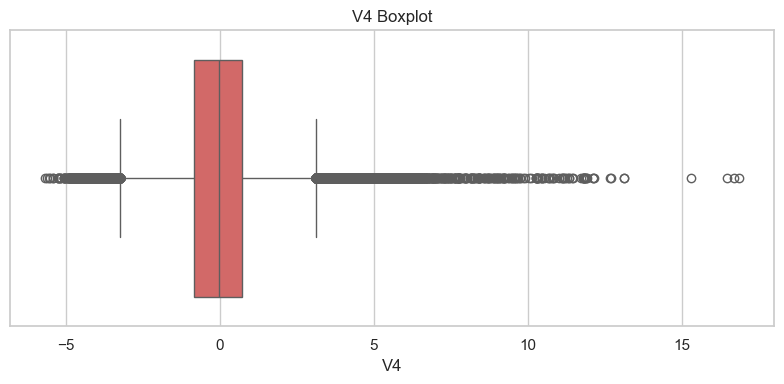

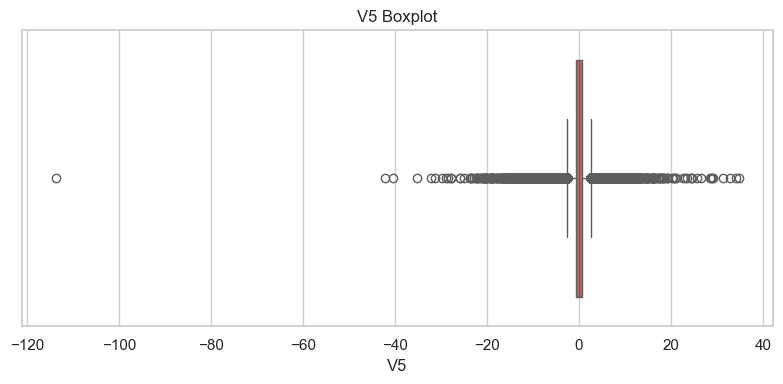

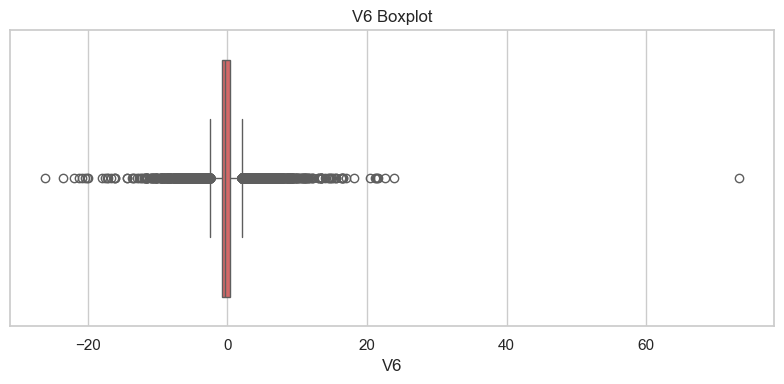

In [16]:
for feature in selected_pca_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[feature], color="#E45756")
    plt.title(f"{feature} Boxplot")
    plt.xlabel(feature)
    plt.tight_layout()
    plt.savefig(NOTEBOOK_FIGURES_DIR / f"{feature.lower()}_boxplot.png", dpi=300, bbox_inches="tight")
    plt.show()

## 8. Outlier Summary

In [17]:
outlier_summary_rows = []

for column in [TIME_COLUMN, AMOUNT_COLUMN, *selected_pca_features]:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_count = int(((df[column] < lower_bound) | (df[column] > upper_bound)).sum())
    outlier_summary_rows.append({
        "column": column,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": outlier_count
    })

outlier_summary = pd.DataFrame(outlier_summary_rows)
outlier_summary.to_csv(NOTEBOOK_TABLES_DIR / "outlier_summary.csv", index=False)
outlier_summary

,column,lower_bound,upper_bound,outlier_count
0,Time,-73435.125000,266937.875000,0
1,Amount,-102.265000,185.375000,31685
2,V1,-4.263980,4.664096,6948
3,V2,-2.701226,2.901188,13390
4,V3,-3.764645,3.901923,3306
5,V4,-3.234807,3.124319,11094
6,V5,-2.642901,2.565290,12221
7,V6,-2.517765,2.145527,22886


## 9. Univariate Findings

- the target distribution remains highly imbalanced after cleaning
- `Amount` remains strongly right-skewed, and the log-transformed version provides a more stable view for later modeling
- `Time` spans the full observation window and may require normalization or feature engineering depending on the model choice
- PCA-based variables vary in spread and outlier behavior, but their direct business interpretation remains limited
- scaling and transformation decisions should be considered before training linear models such as logistic regression

In [ ]:
univariate_report = """# Univariate Analysis Report

## Key Findings

- The target distribution remains highly imbalanced after cleaning.
- `Amount` remains strongly right-skewed, and the log-transformed version provides a more stable view for later modeling.
- `Time` spans the full observation window and may require normalization or feature engineering depending on the model choice.
- PCA-based variables vary in spread and outlier behavior, but their direct business interpretation remains limited.
- Scaling and transformation decisions should be considered before training linear models such as logistic regression.

## Saved Tables

- `reports/tables/05_univariate_analysis/target_distribution_after_cleaning.csv`
- `reports/tables/05_univariate_analysis/summary_statistics.csv`
- `reports/tables/05_univariate_analysis/skewness_summary.csv`
- `reports/tables/05_univariate_analysis/amount_summary.csv`
- `reports/tables/05_univariate_analysis/time_summary.csv`
- `reports/tables/05_univariate_analysis/pca_feature_summary.csv`
- `reports/tables/05_univariate_analysis/outlier_summary.csv`
- `reports/tables/05_univariate_analysis/univariate_report.md`

## Saved Figures

- `reports/figures/05_univariate_analysis/target_distribution_after_cleaning.png`
- `reports/figures/05_univariate_analysis/amount_distribution.png`
- `reports/figures/05_univariate_analysis/amount_boxplot.png`
- `reports/figures/05_univariate_analysis/amount_log_distribution.png`
- `reports/figures/05_univariate_analysis/time_distribution.png`
- `reports/figures/05_univariate_analysis/time_boxplot.png`
- `reports/figures/05_univariate_analysis/v1_distribution.png`
- `reports/figures/05_univariate_analysis/v1_boxplot.png`
- `reports/figures/05_univariate_analysis/v2_distribution.png`
- `reports/figures/05_univariate_analysis/v2_boxplot.png`
- `reports/figures/05_univariate_analysis/v3_distribution.png`
- `reports/figures/05_univariate_analysis/v3_boxplot.png`
- `reports/figures/05_univariate_analysis/v4_distribution.png`
- `reports/figures/05_univariate_analysis/v4_boxplot.png`
- `reports/figures/05_univariate_analysis/v5_distribution.png`
- `reports/figures/05_univariate_analysis/v5_boxplot.png`
- `reports/figures/05_univariate_analysis/v6_distribution.png`
- `reports/figures/05_univariate_analysis/v6_boxplot.png`
"""

report_path = NOTEBOOK_TABLES_DIR / "univariate_report.md"
report_path.write_text(univariate_report, encoding="utf-8")
print(f"Univariate report saved to: {report_path}")

## 10. Next Step

The next notebook should be `06_bivariate_analysis.ipynb`. It should examine relationships between variables and compare feature behavior across the fraud target classes in more detail.